In [3]:
import os
import json
import numpy as np
import shutil
import subprocess
from openEMS import openEMS
from CSXCAD import ContinuousStructure

# 1. PREPARACIÓN DEL ENTORNO RAM
sim_path = "/work/sim_crosstalk"
print(f"[*] 1. Limpiando y preparando {sim_path}...")
if not os.path.exists(sim_path):
    os.makedirs(sim_path)
else:
    for root, dirs, files in os.walk(sim_path):
        for f in files: os.unlink(os.path.join(root, f))
        for d in dirs: shutil.rmtree(os.path.join(root, d))

# 2. CARGA DE GEOMETRÍA
print("[*] 2. Cargando geometría...")
with open('/work/experimentos/geometria_completa.json', 'r') as f:
    geo = json.load(f)

unit = 1e-3
thickness = geo['board_params']['thickness'] * unit
er = geo['board_params']['epsilon_r']

# 3. INICIALIZACIÓN FDTD (8000 pasos = ~1.3ns de simulación)
FDTD = openEMS(EndCriteria=0, NrTS=8000)
CSX = ContinuousStructure()
FDTD.SetCSX(CSX)

# 4. CONSTRUCCIÓN DEL MODELO 3D
print("[*] 3. Construyendo modelo 3D y malla...")
all_x = [p['pos_x'] for p in geo['pads']] + [t['start_x'] for t in geo['tracks']] + [t['end_x'] for t in geo['tracks']]
all_y = [p['pos_y'] for p in geo['pads']] + [t['start_y'] for t in geo['tracks']] + [t['end_y'] for t in geo['tracks']]

margin = 3.0 
min_x, max_x = (min(all_x) - margin) * unit, (max(all_x) + margin) * unit
min_y, max_y = (min(all_y) - margin) * unit, (max(all_y) + margin) * unit

FR4 = CSX.AddMaterial('FR4', epsilon=er)
PEC = CSX.AddMetal('PEC')

FR4.AddBox([min_x, min_y, 0], [max_x, max_y, thickness], priority=0)
PEC.AddBox([min_x, min_y, 0], [max_x, max_y, 0], priority=10) # Plano de masa

def get_thick_line_pts(x1, y1, x2, y2, w):
    dx, dy = x2 - x1, y2 - y1
    L = np.sqrt(dx**2 + dy**2)
    if L == 0: return [[x1-w/2, x1+w/2, x1+w/2, x1-w/2], [y1-w/2, y1-w/2, y1+w/2, y1+w/2]]
    nx, ny = -dy / L * (w/2), dx / L * (w/2)
    return [[x1+nx, x1-nx, x2-nx, x2+nx], [y1+ny, y1-ny, y2-ny, y2+ny]]

for track in geo['tracks']:
    w = track['width'] * unit
    pts = get_thick_line_pts(track['start_x']*unit, track['start_y']*unit, 
                             track['end_x']*unit, track['end_y']*unit, w)
    PEC.AddPolygon(pts, 'z', thickness, priority=20)

for pad in geo['pads']:
    sx, sy = (pad['size_x'] * unit) / 2, (pad['size_y'] * unit) / 2
    px, py = pad['pos_x'] * unit, pad['pos_y'] * unit
    PEC.AddBox([px-sx, py-sy, thickness], [px+sx, py+sy, thickness], priority=20)

# Malla optimizada
mesh = CSX.GetGrid()
mesh.SetDeltaUnit(1)
res_pista = 0.2 * unit 
mesh.AddLine('x', [min_x, max_x] + [p['pos_x']*unit for p in geo['pads']])
mesh.AddLine('y', [min_y, max_y] + [p['pos_y']*unit for p in geo['pads']])
mesh.AddLine('z', [0, thickness, thickness + 2*unit])
mesh.SmoothMeshLines('x', res_pista, ratio=1.5)
mesh.SmoothMeshLines('y', res_pista, ratio=1.5)
mesh.SmoothMeshLines('z', 0.1 * unit, ratio=1.5)

# 5. EXCITACIÓN Y PUERTOS
print("[*] 4. Configurando excitación y puertos...")
f_max = 1e9
# Señal Tanh (Delay 0.2ns, Subida 0.1ns)
formula_escalon = "5 * (1 + tanh((t - 0.2e-9) / 0.1e-9))"
FDTD.SetCustomExcite(formula_escalon.encode('ascii'), 0, f_max)
FDTD.SetBoundaryCond([8, 8, 8, 8, 8, 8])

pad_ag_x, pad_ag_y = 113.41 * unit, 80.46 * unit
pad_vic_x, pad_vic_y = 113.41 * unit, 83.0 * unit

# El puerto 1 lanza 10V. El puerto 2 es pasivo pero mide.
FDTD.AddLumpedPort(1, 50.0, [pad_ag_x, pad_ag_y, 0], [pad_ag_x, pad_ag_y, thickness], 'z', excite=10.0, priority=50)
FDTD.AddLumpedPort(2, 1e6,  [pad_vic_x, pad_vic_y, 0], [pad_vic_x, pad_vic_y, thickness], 'z', excite=0.0, priority=50)

# 6. ESCRITURA Y EJECUCIÓN (BASH PURO)
xml_file = os.path.join(sim_path, 'estructura.xml')
FDTD.Write2XML(xml_file)

print("=========================================")
print(f"[*] LANZANDO EL CIGALA (MULTI-THREAD PURO)")
print("=========================================")

# Ejecutamos OpenEMS en bash forzando los hilos (30 cores)
comando_bash = "export OMP_NUM_THREADS=30 && /opt/openEMS/bin/openEMS estructura.xml"

process = subprocess.Popen(
    comando_bash,
    cwd=sim_path,
    shell=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    print(line, end="")

process.wait()

if process.returncode == 0:
    print("\n✅ SIMULACIÓN EXITOSA.")
else:
    print(f"\n❌ ERROR: El motor falló con código {process.returncode}.")

[*] 1. Limpiando y preparando /work/sim_crosstalk...
[*] 2. Cargando geometría...
[*] 3. Construyendo modelo 3D y malla...
[*] 4. Configurando excitación y puertos...
[*] LANZANDO EL CIGALA (MULTI-THREAD PURO)
 ---------------------------------------------------------------------- 
 | openEMS 64bit -- version v0.0.36-142-g32c5c6b
 | (C) 2010-2025 Thorsten Liebig <thorsten.liebig@gmx.de>  GPL license
 ---------------------------------------------------------------------- 
	Used external libraries:
		CSXCAD -- Version: v0.6.3-100-gd7d70ef
		hdf5   -- Version: 1.10.10
		          compiled against: HDF5 library version: 1.10.10
		tinyxml -- compiled against: 2.6.2
		fparser
		boost  -- compiled against: 1_83
		vtk -- Version: 9.1.0
		       compiled against: 9.1.0

Create FDTD operator (compressed SSE + multi-threading)
FDTD simulation size: 272x81x47 --> 1.0355e+06 FDTD cells 
FDTD timestep is: 1.68426e-13 s; Nyquist rate: 4294967295 timesteps @691 Hz
openEMS::SetupFDTD: Warning, the time

[*] Extrayendo los voltajes de los puertos (Modo Robusto)...
[*] Datos cargados con éxito (1 pasos de tiempo detectados).


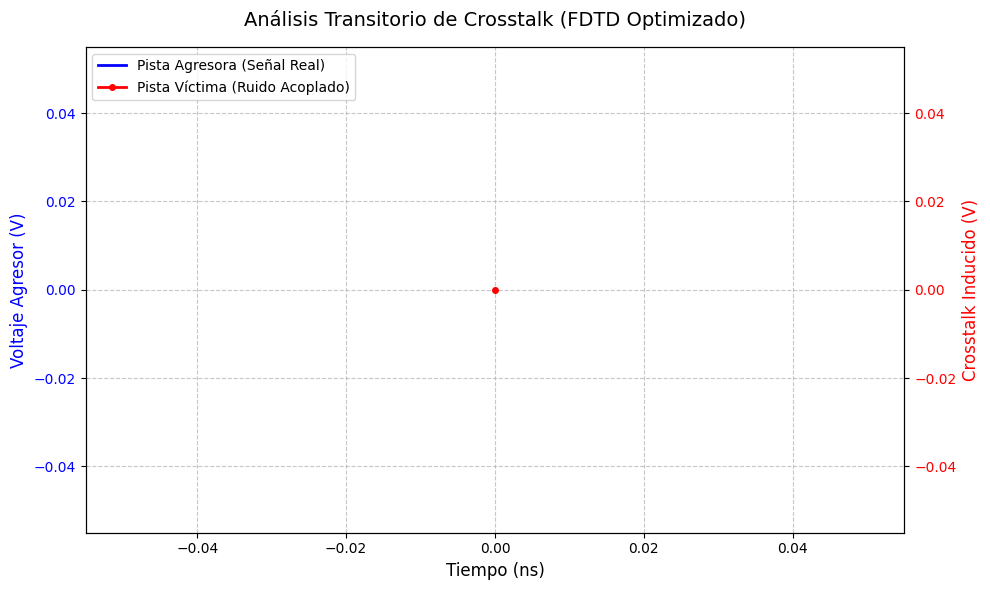

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

sim_path = "/work/sim_crosstalk"
print("[*] Extrayendo los voltajes de los puertos (Modo Robusto)...")

try:
    # --- LA CORRECCIÓN CLAVE ---
    # ndmin=2 obliga a Numpy a cargar los datos como una tabla (matriz 2D),
    # incluso si solo hay una fila válida de datos numéricos.
    p1 = np.loadtxt(os.path.join(sim_path, 'port_ut_1'), comments=['%', '#'], ndmin=2)
    p2 = np.loadtxt(os.path.join(sim_path, 'port_ut_2'), comments=['%', '#'], ndmin=2)
    
    # Comprobamos si realmente tenemos datos para plotear
    if p1.shape[0] == 0 or p2.shape[0] == 0:
        raise ValueError("Los archivos de puerto están vacíos o corruptos.")

    print(f"[*] Datos cargados con éxito ({p1.shape[0]} pasos de tiempo detectados).")

    t_ns = p1[:, 0] * 1e9 # Convertimos el tiempo a ns
    v_agresor = p1[:, 1]
    v_victima = p2[:, 1]
    
    plt.figure(figsize=(10, 6))
    
    ax1 = plt.gca()
    ax1.plot(t_ns, v_agresor, 'b-', label='Pista Agresora (Señal Real)', linewidth=2)
    ax1.set_xlabel('Tiempo (ns)', fontsize=12)
    ax1.set_ylabel('Voltaje Agresor (V)', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Eje derecho para el Crosstalk (que es mucho más pequeño)
    ax2 = ax1.twinx()
    # Si tenemos pocos datos, ploteamos puntos también para verlos mejor
    if p1.shape[0] < 50:
        ax2.plot(t_ns, v_victima, 'ro-', label='Pista Víctima (Ruido Acoplado)', linewidth=2, markersize=4)
    else:
        ax2.plot(t_ns, v_victima, 'r-', label='Pista Víctima (Ruido Acoplado)', linewidth=2)
        
    ax2.set_ylabel('Crosstalk Inducido (V)', color='r', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='r')
    
    plt.title('Análisis Transitorio de Crosstalk (FDTD Optimizado)', fontsize=14, pad=15)
    
    # Unificamos leyendas
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Error al generar la gráfica: {e}")

[*] Extrayendo los voltajes de los puertos (Modo Robusto)...
[*] Datos cargados con éxito (1 pasos de tiempo detectados).


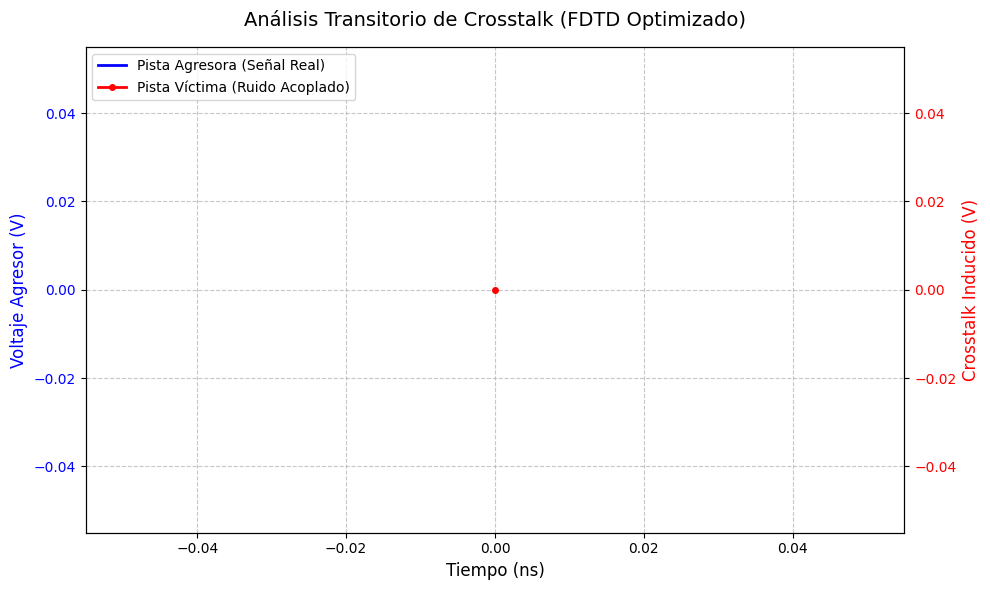

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

sim_path = "/work/sim_crosstalk"
print("[*] Extrayendo los voltajes de los puertos (Modo Robusto)...")

try:
    # --- LA CORRECCIÓN CLAVE ---
    # ndmin=2 obliga a Numpy a cargar los datos como una tabla (matriz 2D),
    # incluso si solo hay una fila válida de datos numéricos.
    p1 = np.loadtxt(os.path.join(sim_path, 'port_ut_1'), comments=['%', '#'], ndmin=2)
    p2 = np.loadtxt(os.path.join(sim_path, 'port_ut_2'), comments=['%', '#'], ndmin=2)
    
    # Comprobamos si realmente tenemos datos para plotear
    if p1.shape[0] == 0 or p2.shape[0] == 0:
        raise ValueError("Los archivos de puerto están vacíos o corruptos.")

    print(f"[*] Datos cargados con éxito ({p1.shape[0]} pasos de tiempo detectados).")

    t_ns = p1[:, 0] * 1e9 # Convertimos el tiempo a ns
    v_agresor = p1[:, 1]
    v_victima = p2[:, 1]
    
    plt.figure(figsize=(10, 6))
    
    ax1 = plt.gca()
    ax1.plot(t_ns, v_agresor, 'b-', label='Pista Agresora (Señal Real)', linewidth=2)
    ax1.set_xlabel('Tiempo (ns)', fontsize=12)
    ax1.set_ylabel('Voltaje Agresor (V)', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Eje derecho para el Crosstalk (que es mucho más pequeño)
    ax2 = ax1.twinx()
    # Si tenemos pocos datos, ploteamos puntos también para verlos mejor
    if p1.shape[0] < 50:
        ax2.plot(t_ns, v_victima, 'ro-', label='Pista Víctima (Ruido Acoplado)', linewidth=2, markersize=4)
    else:
        ax2.plot(t_ns, v_victima, 'r-', label='Pista Víctima (Ruido Acoplado)', linewidth=2)
        
    ax2.set_ylabel('Crosstalk Inducido (V)', color='r', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='r')
    
    plt.title('Análisis Transitorio de Crosstalk (FDTD Optimizado)', fontsize=14, pad=15)
    
    # Unificamos leyendas
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Error al generar la gráfica: {e}")